### 第12章 图像轮廓
#### 12.1 查找和绘制轮廓
- 查找图像轮廓函数为`contours, hierarchy = cv2.findContours(image, mode, method)`， 其中
    - contours 返回的轮廓
        - 类型属性 type(contours) -> <class 'list'>
        - 图像中的轮廓个数 len(contours) 
        - 每个轮廓的点数 len(contours[i]) -> 第i个轮廓的长度（点的个数）
        - 获取每个轮廓内点的形状属性 contours[i].shape
        - 轮廓内的点 contours[i] -> 轮廓内每个点的坐标
    - hierarchy 图像的轮廓层次
        - 外部的轮廓称为父轮廓，内部的轮廓称为子轮廓，每个轮廓 contours[i]有4个元素表示层次关系，没有对应关系时值为-1
            - Next 后一个轮廓的索引编号
            - Previous 前一个轮廓的索引编号
            - First_Child 第一个子轮廓的索引编号
            - Parent 父轮廓的索引编号
    - image 输入图像，8位单通道图像所有非零值被处理为1，零值保持不变，即灰度图会被自动处理为二值图像
    - mode 轮廓检索模式
        - `cv2.RETR_EXTERNAL`：只检测外轮廓
        - `cv2.RETR_LIST`：对检测到的轮廓不建立等级关系
        - `cv2.RETR_CCOMP`：检索所有轮廓并将它们组织成两级层次结构。上层为外边界，下层为内边界
        - `cv2.RETR_TREE`：建立等级树结构的轮廓，仅有两层轮廓时，与`cv2.RETR_CCOMP`层次结构一致。当有多层结构时，`cv2.RETR_CCOMP`仍然只能得到两个层次结构；而`cv2.RETR_TREE`会得到多个层次的结构
    - method 轮廓的近似方法
        - `cv2.CHAIN_APPROX_NONE`：存储所有的轮廓点，相邻两个像素点的位置差不超过1
        - `cv2.CHAIN_APPROX_SIMPLE`：压缩水平方向、垂直方向、对角线方向的元素，只保留该方向的终点坐标
        - `cv2.CHAIN_APPROX_TC89_L1`：使用 teh-Chin1 chain 近似算法的一种风格
        - `cv2.CHAIN_APPROX_TC89_KCOS`：使用 teh-Chin1 chain 近似算法的一种风格
- 注意事项：
    - 源图像必须是灰度二值图。通常情况下，要预先对图像进行阈值分割或者边缘检测，得到合适的二值图像
    - 在 OpenCV 中都是从黑色背景中查找白色图像。因此对象必须是白色的，背景必须是黑色的

- `image = cv2.drawContours(image, contours, contourIdx, color[, thickness[, lineType[, hierarchy[, maxLevel[, offset]]]]])`是绘制图像轮廓函数，也可以写成没有返回值的形式。无论是否具有返回值，该函数都在原始图像上绘制轮廓。其中
    - image 待绘制轮廓的图像，注意函数执行会在image上直接绘制轮廓，需要预先复制副本图像传递给函数使用
    - contours 需要绘制的轮廓，与`cv2.findContours()`的输出相同
    - contoursIdx 需要绘制轮廓的索引，如果该值为负数，表示绘制全部轮廓
    - color 绘制的颜色，用 BGR 表示
    - thickness 表示绘制轮廓时所用画笔粗细的可选值，`-1`表示实心轮廓
    - lineType 表示绘制轮廓时所用线型的可选值
    - hierarchy 对应`cv2.findContours()`输出的层次信息
    - maxLevel 控制所绘制轮廓层次的深度，应为非负数，表示绘制最高层及以下数量层级的轮廓
    - offset 偏移参数，使轮廓偏移到不同位置展示出来
    
- 使用函数`cv2.findContours`和函数`cv2.draawContours`可以将图像的前景区域提取出来

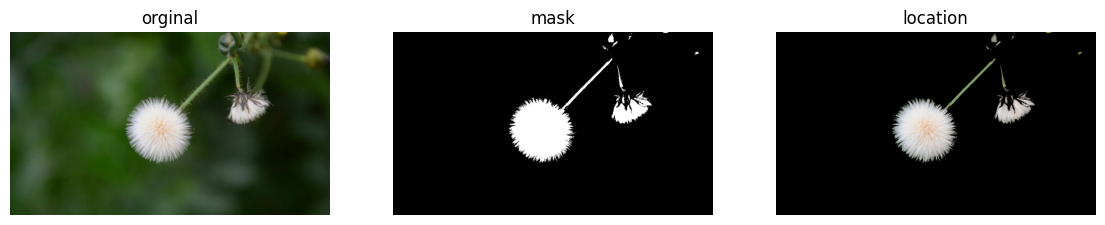

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

import cv2
import numpy as np
o = cv2.imread('loc1.jpg')
gray = cv2.cvtColor(o, cv2.COLOR_BGR2GRAY) 

# cv2.findContours会把所有非零值视为前景，所以需要对图像进行二值化处理，才能找到轮廓，否则几乎整幅图像全都是轮廓 
ret, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)  
contours, hierarchy = cv2.findContours(
                                        binary,
                                        cv2.RETR_LIST,
                                        cv2.CHAIN_APPROX_SIMPLE)  
mask = np.zeros(o.shape, np.uint8)
mask = cv2.drawContours(mask, contours, -1, (255,255,255), -1) 
loc = cv2.bitwise_and(o, mask)

o = cv2.cvtColor(o, cv2.COLOR_BGR2RGB)
mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
loc = cv2.cvtColor(loc, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 4))
plt.subplot(131)
plt.imshow(o)
plt.title("orginal")
plt.axis("off")
plt.subplot(132)
plt.imshow(mask)
plt.title("mask")
plt.axis("off")
plt.subplot(133)
plt.imshow(loc)
plt.title("location")
plt.axis("off")
plt.show()

#### 12.2 轮廓特征
- 获取轮廓矩函数`retval = cv2.moments(array[, binaryImage])`， 其中
    - array 可以是点集或者灰度图像。如果是点集，则函数将整个点集视为一条轮廓
    - binaryImage 当array为图像时，若该值为True，则array内所有非零值均视为1
    - 返回值retval是矩特征，主要包括空间矩、中心矩和归一化中心矩：
        - 零阶矩`m00`表示一个轮廓的面积
        - 中心矩通过减去均值得到平移不变性，因而能够比较不同位置的两个对象是否一致
        - 归一化中心矩通过除以物体尺寸得到缩放不变性

- 计算轮廓的面积`retval = cv2.contourArea(contour [, oriented])`， 其中
    - 返回值retval是面积值
    - contour 是轮廓
    - oriented 为True时，返回值的正/负号表示轮廓是顺时针/逆时针；默认值为False，表示返回值是绝对值

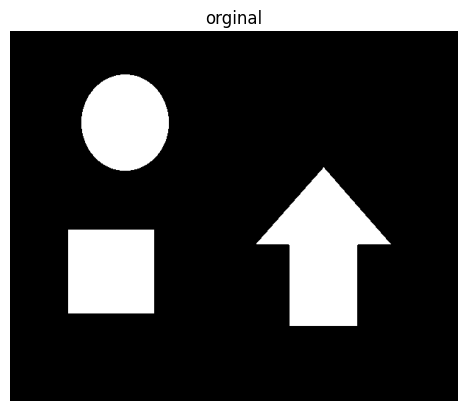

contours[0] area: 13108.0
contours[1] area: 19535.0
contours[2] area: 12058.0


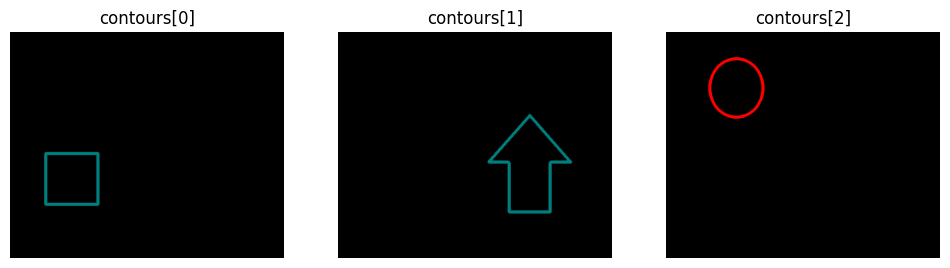

In [17]:
# 筛选出大于指定面积的轮廓
import cv2
import numpy as np

o = cv2.imread('contours.bmp')  
o = cv2.cvtColor(o, cv2.COLOR_BGR2RGB)
plt.imshow(o)
plt.title("orginal")
plt.axis("off")
plt.show()

gray = cv2.cvtColor(o,cv2.COLOR_BGR2GRAY)  
ret, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)  
contours, hierarchy = cv2.findContours(binary, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)  

n = len(contours)
contoursImg = []
plt.figure(figsize=(12,4))
for i in range(n):
    temp = np.zeros(o.shape, np.uint8)
    contoursImg.append(temp)
    print("contours[" + str(i) + "] area: " + str(cv2.contourArea(contours[i])))
    if cv2.contourArea(contours[i]) > 13000:
        # 大于指定面积的用青色表示
        contoursImg[i] = cv2.drawContours(contoursImg[i], contours, i, (127,127,0), 5)
    else:
        # 小于指定面积的用红色表示
        contoursImg[i] = cv2.drawContours(contoursImg[i], contours, i, (0,0,255), 5)
    contoursImg[i] = cv2.cvtColor(contoursImg[i], cv2.COLOR_BGR2RGB)
    plt.subplot(1, n, i+1)
    plt.imshow(contoursImg[i])
    plt.title("contours[" + str(i)+"]")
    plt.axis("off")
plt.show()



- 计算轮廓的长度`retval = cv2.arcLength(curve, closed)`， 其中
    - 返回值retval是轮廓的周长值
    - contour 是轮廓
    - oriented 为True时，表示轮廓是封闭的

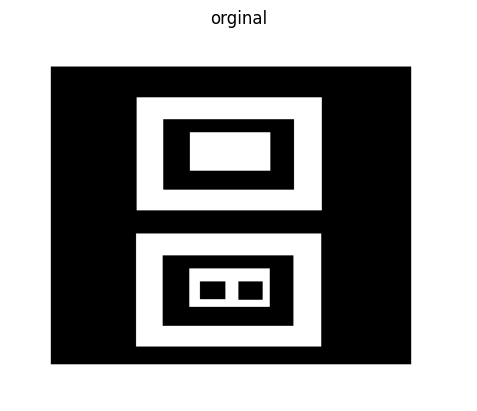

第0个轮廓的长度为: 145
第1个轮廓的长度为: 147
第2个轮廓的长度为: 398
第3个轮廓的长度为: 681
第4个轮廓的长度为: 1004
第5个轮廓的长度为: 398
第6个轮廓的长度为: 681
第7个轮廓的长度为: 1004
第8个轮廓的长度为: 2225
第9个轮廓的长度为: 2794
全部轮廓的总长度为：9480
全部轮廓的平均长度为：948


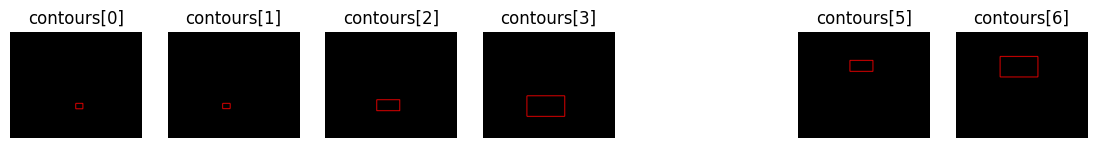

In [ ]:
# 筛选出长度小于平均值的轮廓
import cv2
import numpy as np
o = cv2.imread('contoursLength.bmp')  
o = cv2.cvtColor(o, cv2.COLOR_BGR2RGB)
plt.imshow(o)
plt.title("orginal")
plt.axis("off")
plt.show()

# 获取轮廓
gray = cv2.cvtColor(o,cv2.COLOR_BGR2GRAY)  
ret, binary = cv2.threshold(gray,127,255,cv2.THRESH_BINARY)  
contours, hierarchy = cv2.findContours(binary, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)  
# 计算各个轮廓的长度和平均值
n = len(contours)   
cntLen = []                 # 存储各个轮廓的长度
for i in range(n):
    cntLen.append(cv2.arcLength(contours[i], True))
    print("第"+str(i)+"个轮廓的长度为: %d"%cntLen[i])
Sum = np.sum(cntLen)  # 轮廓长度和
Avr = Sum/n     # 轮廓长度平均值
print("全部轮廓的总长度为：%d" %Sum)
print("全部轮廓的平均长度为：%d" %Avr)

contoursImg = []
plt.figure(figsize=(20,4))
for i in range(n):
    temp = np.zeros(o.shape,np.uint8)
    contoursImg.append(temp)
    contoursImg[i] = cv2.drawContours(contoursImg[i], contours, i, (0,0,255), 3)
    if cv2.arcLength(contours[i],True) < Avr: # 显示长度小于平均值的轮廓  
        contoursImg[i] = cv2.cvtColor(contoursImg[i], cv2.COLOR_BGR2RGB)
        plt.subplot(1, n, i+1)
        plt.imshow(contoursImg[i])
        plt.title("contours[" + str(i)+"]")
        plt.axis("off")  
plt.show()